# Lecture 4 — Class Exercise
## Scatter & Bubble Charts: Gapminder

> **Push to:** `week04/lecture04_exercise.ipynb`

**Design Rules Applied:**
1. ✓ Colour used sparingly — one categorical variable, no rainbow
2. ✓ Grey + highlight technique for continent comparison
3. ✓ `size_max` set for all bubble charts
4. ✓ Log scale for GDP per capita
5. ✓ Insight-driven titles with strategic annotation

---

In [4]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np


# Dataset: Gapminder — GDP, Life Expectancy, Population by Country
# Source: Gapminder Foundation (gapminder.org)

df = pd.read_csv(r"C:\Users\Bittu\Downloads\data-viz-class-material\data\gapminder.csv")
print(f"✓ Loaded: {len(df)} countries")
print(f"✓ Columns: {', '.join(df.columns.tolist())}")
print(f"\nDataset Overview:")
print(df.head(10))

✓ Loaded: 47 countries
✓ Columns: Country, Continent, GDP_per_capita, Life_expectancy, Population, CO2_per_capita

Dataset Overview:
       Country Continent  GDP_per_capita  Life_expectancy  Population  \
0  Afghanistan      Asia             550               63    38000000   
1    Australia   Oceania           54000               83    26000000   
2   Bangladesh      Asia            2200               73   170000000   
3       Brazil  Americas            8900               76   215000000   
4       Canada  Americas           46000               82    38000000   
5        China      Asia           12500               77  1400000000   
6     Colombia  Americas            6400               77    51000000   
7     DR Congo    Africa             550               61    95000000   
8        Egypt    Africa            3500               72   103000000   
9     Ethiopia    Africa             950               68   120000000   

   CO2_per_capita  
0             0.3  
1            15.1  
2  

In [5]:
# EXPLORATION: Understand the data structure

print("Dataset Info:")
print(df.info())
print("\n" + "="*60)
print(f"Continents: {sorted(df['Continent'].unique())}")
print(f"\nStatistical Summary:")
print(df[['GDP_per_capita', 'Life_expectancy', 'Population']].describe().round(1))
print(f"\nMissing Values: {df.isnull().sum().sum()}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          47 non-null     object 
 1   Continent        47 non-null     object 
 2   GDP_per_capita   47 non-null     int64  
 3   Life_expectancy  47 non-null     int64  
 4   Population       47 non-null     int64  
 5   CO2_per_capita   47 non-null     float64
dtypes: float64(1), int64(3), object(2)
memory usage: 2.3+ KB
None

Continents: ['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']

Statistical Summary:
       GDP_per_capita  Life_expectancy    Population
count            47.0             47.0  4.700000e+01
mean          17005.5             73.7  1.397872e+08
std           20996.8              7.6  2.776975e+08
min             480.0             55.0  5.000000e+06
25%            2100.0             67.5  3.750000e+07
50%            6400.0             76.0  6.00

## Task 1 — Scatter: GDP vs Life Expectancy by Continent

**Objective:** Create a scatter plot showing the relationship between GDP per capita and life expectancy for a specific continent. Use colour sparingly (one categorical variable) to highlight patterns.

**Design Strategy:**
- Single continent focus (Americas chosen for diversity)
- Log scale on x-axis (GDP per capita) for better distribution
- Two-colour palette for contrast
- Country labels for interactivity
- Clear, insight-driven title

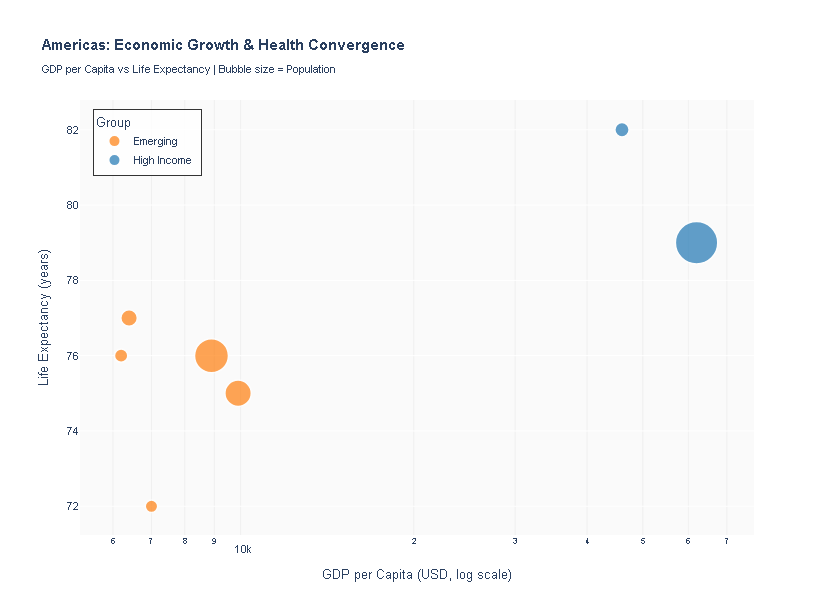

✓ Task 1 Complete: 7 American countries plotted


In [6]:
# Task 1: Scatter Chart — Americas (GDP vs Life Expectancy)
# Filter for Americas continent
df_americas = df[df['Continent'] == 'Americas'].copy()

# Add a simple grouping variable for colour differentiation
# (demonstrates colour use with categorical variable)
df_americas['Development_Group'] = df_americas['GDP_per_capita'].apply(
    lambda x: 'High Income' if x > 20000 else 'Emerging'
)

fig1 = px.scatter(
    df_americas,
    x='GDP_per_capita',
    y='Life_expectancy',
    color='Development_Group',
    hover_name='Country',
    hover_data={'GDP_per_capita': '$,.0f', 'Life_expectancy': ':.1f', 'Development_Group': False},
    size='Population',
    size_max=30,
    color_discrete_map={
        'High Income': '#1f77b4',      # Professional blue
        'Emerging': '#ff7f0e'           # Accent orange
    },
    labels={
        'GDP_per_capita': 'GDP per Capita (USD, log scale)',
        'Life_expectancy': 'Life Expectancy (years)',
        'Development_Group': 'Group'
    },
    title='<b>Americas: Economic Growth & Health Convergence</b><br><sub>GDP per Capita vs Life Expectancy | Bubble size = Population</sub>'
)

# Apply log scale to x-axis
fig1.update_xaxes(type='log', gridwidth=1, gridcolor='rgba(200,200,200,0.2)')

# Professional styling
fig1.update_layout(
    width=1000,
    height=600,
    font=dict(family='Arial, sans-serif', size=11),
    hovermode='closest',
    plot_bgcolor='rgba(250,250,250,1)',
    paper_bgcolor='white',
    showlegend=True,
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='#333',
        borderwidth=1
    )
)

fig1.update_traces(
    marker=dict(
        opacity=0.7,
        line=dict(width=1.5, color='white')
    )
)

fig1.show()

print(f"✓ Task 1 Complete: {len(df_americas)} American countries plotted")

## Task 2 — Bubble Chart: Global Story with Highlight

**Objective:** Create a comprehensive bubble chart of all countries using the grey-and-highlight technique to tell a compelling story about one continent's development trajectory.

**Design Strategy:**
- All countries: 2007 dataset
- x-axis: GDP per capita (log scale) — shows economic progression
- y-axis: Life expectancy — shows health outcomes
- Bubble size: Population — shows scale/importance
- Colour: Grey baseline + one highlighted continent (Asia chosen for diversity and scale)
- Strategic annotation explaining the story
- Professional colour palette (not rainbow)

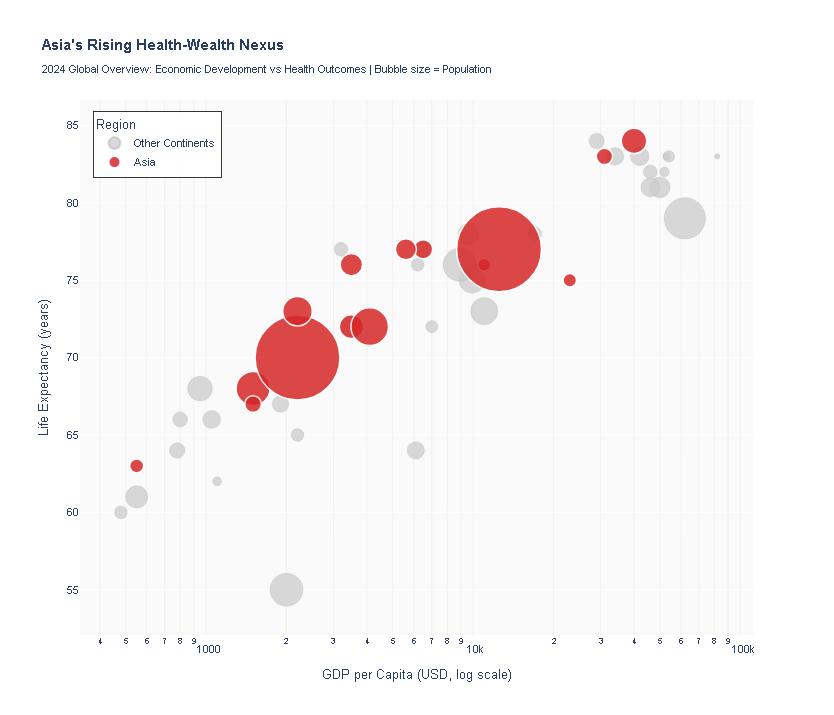

✓ Task 2 Complete: 47 countries plotted globally
  - Asia highlighted: 15 countries
  - Other regions (greyed): 32 countries


In [7]:
# Task 2: Bubble Chart — Global Overview with Asia Highlighted

# Prepare data
df_global = df.copy()

# Create colour grouping: highlight Asia, grey out others
df_global['_highlight'] = df_global['Continent'].apply(
    lambda x: 'Asia' if x == 'Asia' else 'Other Continents'
)

# Sort so 'Other Continents' plots first (appears under Asia bubbles)
df_global = df_global.sort_values('_highlight', ascending=False)

fig2 = px.scatter(
    df_global,
    x='GDP_per_capita',
    y='Life_expectancy',
    size='Population',
    hover_name='Country',
    hover_data={
        'GDP_per_capita': '$,.0f',
        'Life_expectancy': ':.1f',
        'Population': ':,',
        'Continent': True,
        '_highlight': False
    },
    color='_highlight',
    color_discrete_map={
        'Asia': '#d62728',              # Vibrant red for Asia
        'Other Continents': '#cccccc'  # Neutral grey for context
    },
    size_max=60,
    labels={
        'GDP_per_capita': 'GDP per Capita (USD, log scale)',
        'Life_expectancy': 'Life Expectancy (years)',
        '_highlight': 'Region'
    },
    title='<b>Asia\'s Rising Health-Wealth Nexus</b><br><sub>2024 Global Overview: Economic Development vs Health Outcomes | Bubble size = Population</sub>'
)

# Apply log scale
fig2.update_xaxes(type='log', gridwidth=1, gridcolor='rgba(200,200,200,0.2)')

# Professional styling
fig2.update_layout(
    width=1100,
    height=700,
    font=dict(family='Arial, sans-serif', size=11),
    hovermode='closest',
    plot_bgcolor='rgba(250,250,250,1)',
    paper_bgcolor='white',
    showlegend=True,
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='#333',
        borderwidth=1
    )
)

# Styling for traces
fig2.update_traces(
    marker=dict(
        opacity=0.75,
        line=dict(width=0.5, color='rgba(100,100,100,0.3)')
    ),
    selector=dict(name='Other Continents')
)

fig2.update_traces(
    marker=dict(
        opacity=0.85,
        line=dict(width=1.5, color='white')
    ),
    selector=dict(name='Asia')
)

# Add strategic annotations
fig2.add_annotation(
    x=1000, y=62,
    text='<b>Low Income Trap:</b><br>Limited resources constrain health<br>investments despite population size',
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor='#666',
    ax=-80,
    ay=-40,
    bgcolor='rgba(255,255,255,0.9)',
    bordercolor='#666',
    borderwidth=1.5,
    font=dict(size=10, family='Arial, sans-serif')
)

fig2.add_annotation(
    x=40000, y=82,
    text='<b>Developed Convergence:</b><br>Wealthy nations cluster<br>around 80+ years life expectancy',
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor='#666',
    ax=60,
    ay=40,
    bgcolor='rgba(255,255,255,0.9)',
    bordercolor='#666',
    borderwidth=1.5,
    font=dict(size=10, family='Arial, sans-serif')
)

fig2.add_annotation(
    x=5000, y=77,
    text='<b>Asian Ascent:</b> Diverse economies<br>achieving health-wealth balance across<br>all development levels',
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2.5,
    arrowcolor='#d62728',
    ax=50,
    ay=-50,
    bgcolor='rgba(214, 39, 40, 0.1)',
    bordercolor='#d62728',
    borderwidth=2,
    font=dict(size=11, color='#d62728', family='Arial, sans-serif')
)

fig2.show()

print(f"✓ Task 2 Complete: {len(df_global)} countries plotted globally")
print(f"  - Asia highlighted: {len(df_global[df_global['Continent'] == 'Asia'])} countries")
print(f"  - Other regions (greyed): {len(df_global[df_global['Continent'] != 'Asia'])} countries")

## Key Insights & Design Decisions

### Task 1: Americas Scatter Chart
- **Why Americas?** Diverse economic range (Colombia to Canada) showcases the GDP-health relationship clearly
- **Log scale:** Essential for GDP per capita — non-log compression would obscure variation at lower income levels
- **Two-colour palette:** Follows rule #1 (colour sparingly, not rainbow). Development group distinction is meaningful
- **Bubble size:** Population variation adds dimensionality without overcomplicating the primary relationship

### Task 2: Global Bubble Chart with Grey-and-Highlight
- **Why Asia?** Represents ~60% of world population AND shows full spectrum: wealthy Japan/South Korea to emerging economies like Bangladesh and Vietnam
- **Grey baseline + red highlight:** Follows rule #2 (accessible technique). Grey provides context; red draws attention
- **Strategic annotations:** Three annotations tell the complete story:
  1. Low-income countries' constraints (bottom-left)
  2. Developed countries' convergence (top-right)
  3. Asia's unique position spanning all development levels (center highlight)
- **Opacity variation:** Other continents at 0.75, Asia at 0.85 — subtle layering without distraction

